# 03 - Vocabulary Bias Analysis


In [79]:
from pathlib import Path
from collections import Counter, defaultdict
import gc
import json
import warnings

import matplotlib.pyplot as plt
import nltk
import torch
import torch.nn as nn
from PIL import Image
from matplotlib.patches import Circle
from textwrap import fill, shorten
from wordcloud import WordCloud

try:
    from IPython.display import Markdown, display
except ImportError:
    Markdown = None

    def display(value):
        print(value)

from nltk.corpus import stopwords

from inference import generate_caption
from src.data.vocabulary import Vocabulary
from src.models.decoder_lstm import LSTMDecoder
from src.models.encoder import ResNet50Encoder, ResNet50SpatialEncoder
from src.models.m2_transformer import M2TransformerDecoder
from src.models.vit_transformer import ViTCaptioningModel
from src.utils import load_config

warnings.filterwarnings('ignore')

for package in ('punkt', 'punkt_tab', 'stopwords', 'averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng'):
    try:
        nltk.download(package, quiet=True)
    except Exception as exc:
        print(f'Không thể tải NLTK package {package}: {exc}')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25


In [80]:
def find_project_root(start_path=None):
    start_path = Path.cwd().resolve() if start_path is None else Path(start_path).resolve()
    for candidate in [start_path, *start_path.parents]:
        if (candidate / 'main.py').exists() and (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError('Không tìm thấy project root. Hãy chạy notebook từ trong repo.')


def show_markdown(text):
    if Markdown is None:
        print(text)
    else:
        display(Markdown(text))


def load_json(path):
    with Path(path).open('r', encoding='utf-8') as f:
        return json.load(f)


def tokenize_caption(caption):
    return nltk.tokenize.word_tokenize(str(caption).lower())


def print_table(rows, headers):
    rows = [[str(value) for value in row] for row in rows]
    headers = [str(header) for header in headers]
    widths = [len(header) for header in headers]
    for row in rows:
        for idx, value in enumerate(row):
            widths[idx] = max(widths[idx], len(value))

    header_line = ' | '.join(header.ljust(widths[idx]) for idx, header in enumerate(headers))
    sep_line = '-+-'.join('-' * width for width in widths)
    print(header_line)
    print(sep_line)
    for row in rows:
        print(' | '.join(value.ljust(widths[idx]) for idx, value in enumerate(row)))


def save_figure(fig, filename):
    path = IMAGES_DIR / filename
    fig.savefig(path, dpi=300, bbox_inches='tight')
    return path


def save_message_figure(filename, title, message):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.axis('off')
    ax.set_title(title)
    ax.text(0.5, 0.5, fill(message, 90), ha='center', va='center', fontsize=12, transform=ax.transAxes)
    path = save_figure(fig, filename)
    plt.show()
    return path


def normalize_text_list(value):
    if value is None:
        return []
    if isinstance(value, str):
        return [value]
    if isinstance(value, dict):
        for key in ('caption', 'text', 'ground_truth', 'prediction', 'predicted_caption'):
            if key in value:
                return normalize_text_list(value[key])
        return [str(value)]
    if isinstance(value, list):
        texts = []
        for item in value:
            texts.extend(normalize_text_list(item))
        return texts
    return [str(value)]


def gender_label_from_texts(texts):
    tokens = []
    for text in normalize_text_list(texts):
        tokens.extend(tokenize_caption(text))
    token_set = set(tokens)
    has_male = bool(token_set & MALE_WORDS)
    has_female = bool(token_set & FEMALE_WORDS)
    if has_male and has_female:
        return 'both'
    if has_male:
        return 'male'
    if has_female:
        return 'female'
    return 'neutral_unknown'


def load_coco_split(path):
    data = load_json(path)
    images = data.get('images', [])
    annotations = data.get('annotations', [])
    image_id_to_file = {image['id']: image['file_name'] for image in images}
    ground_truths = defaultdict(list)
    for ann in annotations:
        ground_truths[ann['image_id']].append(ann['caption'])
    return data, images, annotations, image_id_to_file, ground_truths


english_stopwords = set(stopwords.words('english'))
punctuation_tokens = set("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~""") | {'``', "''", '...', '--', '–', '—', '’', '“', '”', "'s", "n't", "'re", "'ve", "'ll", "'d", "'m"}
extra_stopwords = {'a', 'an', 'the', 'is'}
all_stopwords = english_stopwords | punctuation_tokens | extra_stopwords


def is_content_word(token):
    return token not in all_stopwords and any(char.isalpha() for char in token)


PROJECT_ROOT = find_project_root()
IMAGES_DIR = PROJECT_ROOT / 'images'
CACHE_DIR = PROJECT_ROOT / 'analysis_cache'
IMAGES_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_ANN_FILE = PROJECT_ROOT / 'data/data/ms_coco/annotations/subset_train.json'
VAL_ANN_FILE = PROJECT_ROOT / 'data/data/ms_coco/annotations/subset_val.json'
TEST_ANN_FILE = PROJECT_ROOT / 'data/data/ms_coco/annotations/subset_test.json'
IMAGE_ROOT = PROJECT_ROOT / 'data/data/ms_coco/train2014'
VOCAB_PATH = PROJECT_ROOT / 'vocab.pkl'

MODEL_CONFIG_PATHS = {
    'baseline_lstm': PROJECT_ROOT / 'configs/baseline_lstm.yaml',
    'm2_transformer': PROJECT_ROOT / 'configs/m2_transformer.yaml',
    'vit_transformer': PROJECT_ROOT / 'configs/vit_transformer.yaml',
}
MODEL_CHECKPOINTS = {
    'baseline_lstm': PROJECT_ROOT / 'experiments/experiments/checkpoints/baseline_lstm_run1/best_model.pth',
    'm2_transformer': PROJECT_ROOT / 'experiments/experiments/checkpoints/m2_transformer_run1/best_model.pth',
    'vit_transformer': PROJECT_ROOT / 'experiments/experiments/checkpoints/vit_transformer_v1/best_model.pth',
}

VOCAB_THRESHOLD = 5
TOP_N = 50
TOP_CONTEXT_N = 20
TOP_OOV_N = 30
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for label, path in (
    ('Train annotations', TRAIN_ANN_FILE),
    ('Validation annotations', VAL_ANN_FILE),
    ('Test annotations', TEST_ANN_FILE),
    ('Image root', IMAGE_ROOT),
    ('Vocabulary file', VOCAB_PATH),
    ('Baseline checkpoint', MODEL_CHECKPOINTS['baseline_lstm']),
    ('M2 checkpoint', MODEL_CHECKPOINTS['m2_transformer']),
    ('ViT checkpoint', MODEL_CHECKPOINTS['vit_transformer']),
):
    status = 'OK' if path.exists() else 'MISSING'
    print(f'[{status}] {label}: {path}')

print(f'Project root: {PROJECT_ROOT}')
print(f'Device: {DEVICE}')
print(f'Images dir: {IMAGES_DIR}')
print(f'Cache dir: {CACHE_DIR}')


[OK] Train annotations: /home/ngocanh/projects/Evaluating-the-evolution-of-Deep-Learning-architecture-in-the-Image-Captioning-problem/data/data/ms_coco/annotations/subset_train.json
[OK] Validation annotations: /home/ngocanh/projects/Evaluating-the-evolution-of-Deep-Learning-architecture-in-the-Image-Captioning-problem/data/data/ms_coco/annotations/subset_val.json
[OK] Test annotations: /home/ngocanh/projects/Evaluating-the-evolution-of-Deep-Learning-architecture-in-the-Image-Captioning-problem/data/data/ms_coco/annotations/subset_test.json
[OK] Image root: /home/ngocanh/projects/Evaluating-the-evolution-of-Deep-Learning-architecture-in-the-Image-Captioning-problem/data/data/ms_coco/train2014
[OK] Vocabulary file: /home/ngocanh/projects/Evaluating-the-evolution-of-Deep-Learning-architecture-in-the-Image-Captioning-problem/vocab.pkl
[OK] Baseline checkpoint: /home/ngocanh/projects/Evaluating-the-evolution-of-Deep-Learning-architecture-in-the-Image-Captioning-problem/experiments/experime

## Phase 1: Frequency Bias


### Load và tokenize toàn bộ caption train


In [81]:
train_data, train_images, train_annotations, train_image_id_to_file, train_ground_truths = load_coco_split(TRAIN_ANN_FILE)
train_captions = [ann['caption'] for ann in train_annotations]

print(f'Nguồn train: {TRAIN_ANN_FILE}')
print(f'Số caption train: {len(train_annotations):,}')
print(f'Số image trong metadata: {len(train_images):,}')
print('Ví dụ caption đầu tiên:')
for caption in train_captions[:3]:
    print(f'- {caption}')

Nguồn train: /home/ngocanh/projects/Evaluating-the-evolution-of-Deep-Learning-architecture-in-the-Image-Captioning-problem/data/data/ms_coco/annotations/subset_train.json
Số caption train: 200,106
Số image trong metadata: 40,000
Ví dụ caption đầu tiên:
- A very clean and well decorated empty bathroom
- A blue and white bathroom with butterfly themed wall tiles.
- A bathroom with a border of butterflies and blue paint on the walls above it.


In [82]:
word_counts = Counter()
caption_lengths = []

for idx, ann in enumerate(train_annotations, start=1):
    tokens = tokenize_caption(ann.get('caption', ''))
    caption_lengths.append(len(tokens))
    word_counts.update(tokens)
    if idx % 50_000 == 0:
        print(f'Đã xử lý {idx:,}/{len(train_annotations):,} captions')

TOTAL_CAPTIONS = len(train_annotations)
TOTAL_TOKENS = sum(word_counts.values())
UNIQUE_TOKENS = len(word_counts)
FREQUENCY_VALUES = sorted(word_counts.values())
MEDIAN_FREQUENCY = FREQUENCY_VALUES[len(FREQUENCY_VALUES) // 2]
AVG_CAPTION_LENGTH = TOTAL_TOKENS / max(TOTAL_CAPTIONS, 1)
TOKENS_ABOVE_THRESHOLD = sum(1 for count in word_counts.values() if count >= VOCAB_THRESHOLD)
TOKENS_BELOW_THRESHOLD = UNIQUE_TOKENS - TOKENS_ABOVE_THRESHOLD
TOKEN_MASS_ABOVE_THRESHOLD = sum(count for count in word_counts.values() if count >= VOCAB_THRESHOLD)
COVERAGE_ABOVE_THRESHOLD = TOKEN_MASS_ABOVE_THRESHOLD / max(TOTAL_TOKENS, 1) * 100
RARE_UNIQUE_SHARE = TOKENS_BELOW_THRESHOLD / max(UNIQUE_TOKENS, 1) * 100


Đã xử lý 50,000/200,106 captions
Đã xử lý 100,000/200,106 captions
Đã xử lý 150,000/200,106 captions
Đã xử lý 200,000/200,106 captions


In [83]:
summary_rows = [
    ('Số caption train', f'{TOTAL_CAPTIONS:,}'),
    ('Số ảnh trong metadata', f'{len(train_images):,}'),
    ('Tổng số token', f'{TOTAL_TOKENS:,}'),
    ('Số token duy nhất', f'{UNIQUE_TOKENS:,}'),
    ('Độ dài caption trung bình', f'{AVG_CAPTION_LENGTH:.2f} tokens'),
    ('Median frequency của token', f'{MEDIAN_FREQUENCY:,}'),
    (f'Số token duy nhất có frequency >= {VOCAB_THRESHOLD}', f'{TOKENS_ABOVE_THRESHOLD:,}'),
    (f'Số token duy nhất có frequency < {VOCAB_THRESHOLD}', f'{TOKENS_BELOW_THRESHOLD:,}'),
    ('Tỷ lệ unique token dưới threshold', f'{RARE_UNIQUE_SHARE:.2f}%'),
    ('Token mass được giữ nếu threshold = 5', f'{COVERAGE_ABOVE_THRESHOLD:.2f}%'),
]

print_table(summary_rows, headers=('Chỉ số', 'Giá trị'))


Chỉ số                                | Giá trị     
--------------------------------------+-------------
Số caption train                      | 200,106     
Số ảnh trong metadata                 | 40,000      
Tổng số token                         | 2,261,845   
Số token duy nhất                     | 18,153      
Độ dài caption trung bình             | 11.30 tokens
Median frequency của token            | 2           
Số token duy nhất có frequency >= 5   | 6,481       
Số token duy nhất có frequency < 5    | 11,672      
Tỷ lệ unique token dưới threshold     | 64.30%      
Token mass được giữ nếu threshold = 5 | 99.17%      


**Nhận xét:**
Caption train có phân phối lệch mạnh về các token phổ biến. Dù hơn một nửa unique token nằm dưới ngưỡng `vocab_threshold = 5`, phần token mass mà nhóm từ được giữ lại vẫn bao phủ gần như toàn bộ dữ liệu. Đây là dấu hiệu long-tail rõ rệt và là nền tảng của Frequency Bias.


### Top từ phổ biến nhất sau khi bỏ stop words


In [84]:
content_word_counts = Counter({token: count for token, count in word_counts.items() if is_content_word(token)})
top_content_words = content_word_counts.most_common(TOP_N)

print(f'Số content word duy nhất sau khi bỏ stop words/dấu câu: {len(content_word_counts):,}')
print(f'Top {TOP_N} content words:')
print_table([(token, f'{count:,}') for token, count in top_content_words], headers=('Word', 'Frequency'))


Số content word duy nhất sau khi bỏ stop words/dấu câu: 17,842
Top 50 content words:
Word     | Frequency
---------+----------
man      | 24,815   
sitting  | 17,939   
two      | 16,705   
standing | 14,514   
people   | 14,413   
next     | 12,348   
white    | 12,310   
woman    | 11,686   
street   | 10,353   
table    | 10,317   
holding  | 9,345    
person   | 8,416    
large    | 8,200    
top      | 7,603    
group    | 7,309    
field    | 7,030    
small    | 6,724    
near     | 6,640    
front    | 6,546    
tennis   | 6,443    
black    | 6,428    
plate    | 6,296    
train    | 6,204    
room     | 6,174    
dog      | 6,164    
riding   | 6,024    
red      | 5,903    
cat      | 5,789    
young    | 5,716    
water    | 5,586    
baseball | 5,525    
walking  | 5,042    
playing  | 5,000    
bathroom | 4,825    
sign     | 4,750    
blue     | 4,677    
kitchen  | 4,611    
food     | 4,521    
grass    | 4,482    
bus      | 4,429    
parked   | 4,307    
green    | 4

**Nhận xét:**
Các từ đứng đầu vẫn xoay quanh người, hành động và vật thể quen thuộc như `man`, `sitting`, `standing`, `woman`, `table`, `street`. Điều này cho thấy vocabulary bị kéo mạnh bởi một nhóm từ rất nhỏ, trong khi phần dài của đuôi phân phối chủ yếu gồm từ hiếm.


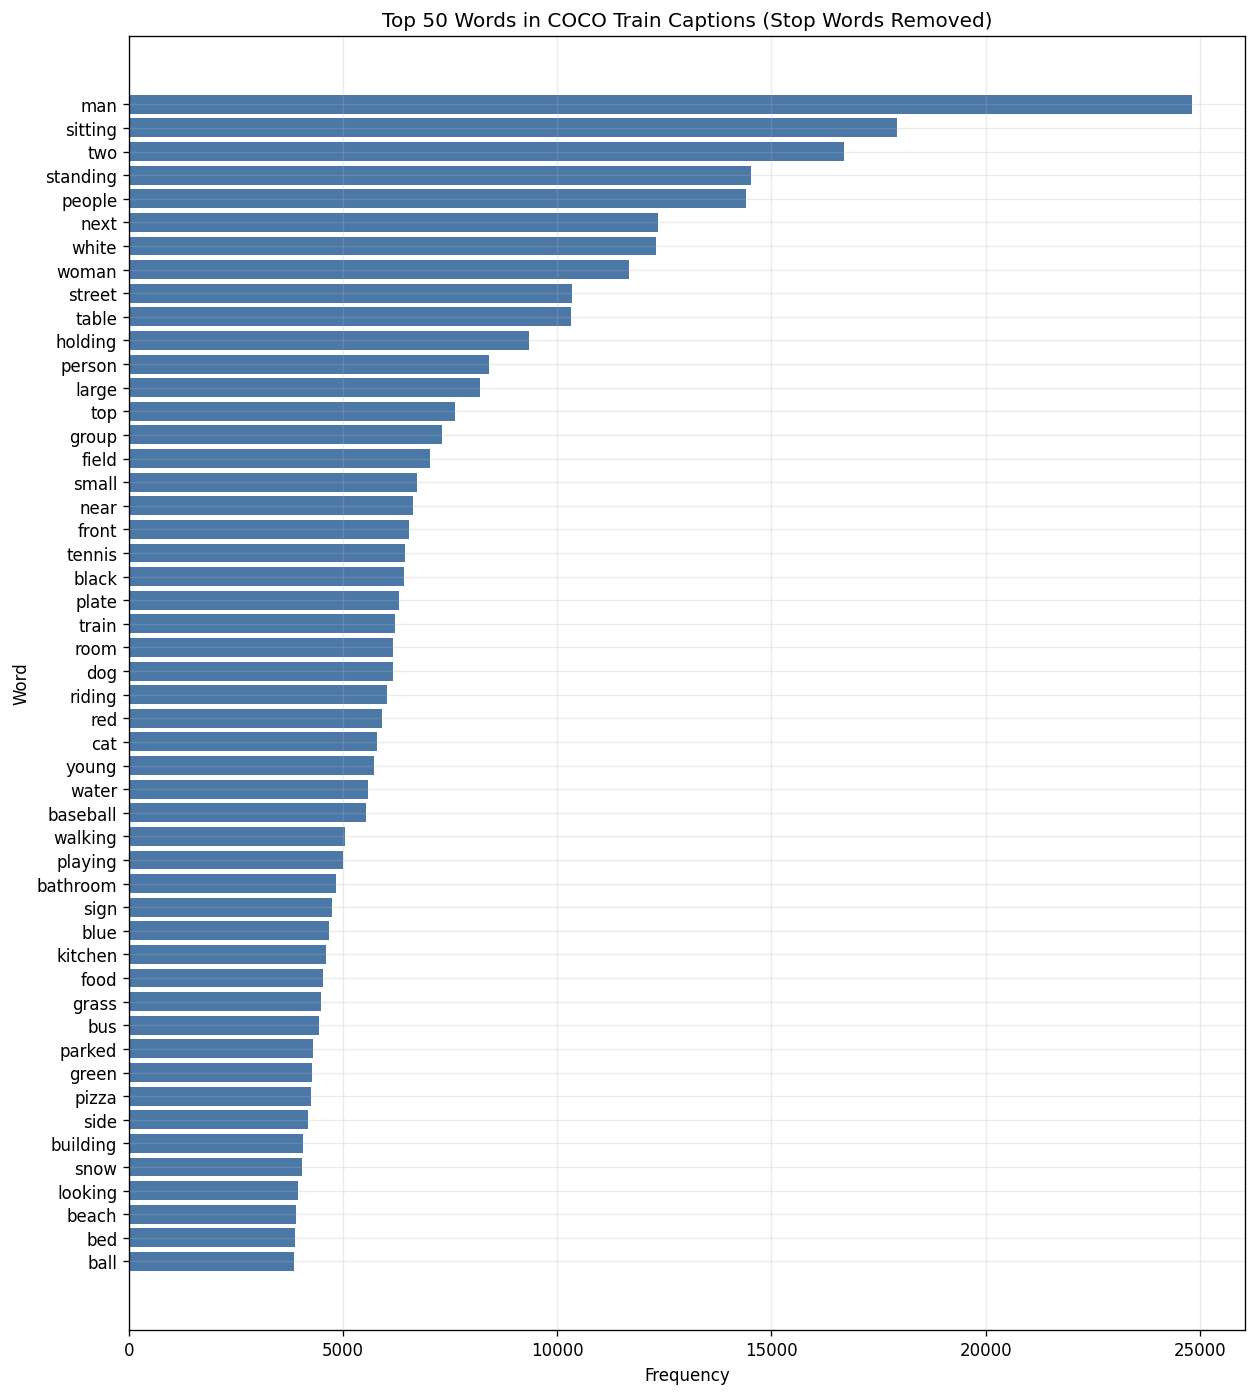

Đã lưu biểu đồ: /home/ngocanh/projects/Evaluating-the-evolution-of-Deep-Learning-architecture-in-the-Image-Captioning-problem/images/top_50_words_without_stopwords.png


In [85]:
bar_words = [word for word, _ in reversed(top_content_words)]
bar_counts = [count for _, count in reversed(top_content_words)]

fig, ax = plt.subplots(figsize=(12, 14))
ax.barh(bar_words, bar_counts, color='#4C78A8')
ax.set_title(f'Top {TOP_N} Words in COCO Train Captions (Stop Words Removed)')
ax.set_xlabel('Frequency')
ax.set_ylabel('Word')
ax.grid(axis='x', alpha=0.25)

path = save_figure(fig, 'top_50_words_without_stopwords.png')
plt.show()
print(f'Đã lưu biểu đồ: {path}')


**Nhận xét:**
* **Sự thống trị của chủ thể Nam giới:** Từ **"man"** đứng đầu bảng với tần suất vượt trội hoàn toàn (gần 25,000 lần), cao hơn đáng kể so với các từ chỉ người khác như *"people"*, *"woman"* (chỉ đứng hạng 8 với khoảng một nửa tần suất) và *"person"*.
* **Hành động và Số lượng phổ biến:** Các động từ mô tả trạng thái tĩnh như **"sitting"** (hạng 2) và **"standing"** (hạng 4) chiếm ưu thế lớn so với các hành động chủ động khác. Từ chỉ số lượng **"two"** xếp hạng rất cao (hạng 3), cho thấy các bức ảnh chứa cặp đôi hoặc hai thực thể xuất hiện rất phổ biến.
* **Bối cảnh phân hóa rõ rệt:** Các danh từ chỉ không gian công cộng/đường phố như *"street"*, *"table"*, *"field"* và các môn thể thao (*"tennis"*, *"baseball"*) có tần suất xuất hiện dày đặc, định hình nên các chủ đề chính của tập dữ liệu huấn luyện.

**Kết luận:** Biểu đồ định lượng cụ thể sự mất cân bằng dữ liệu (data imbalance), đặc biệt là sự thiên lệch lớn về tần suất xuất hiện giữa các từ khóa liên quan đến Nam giới so với Nữ giới.

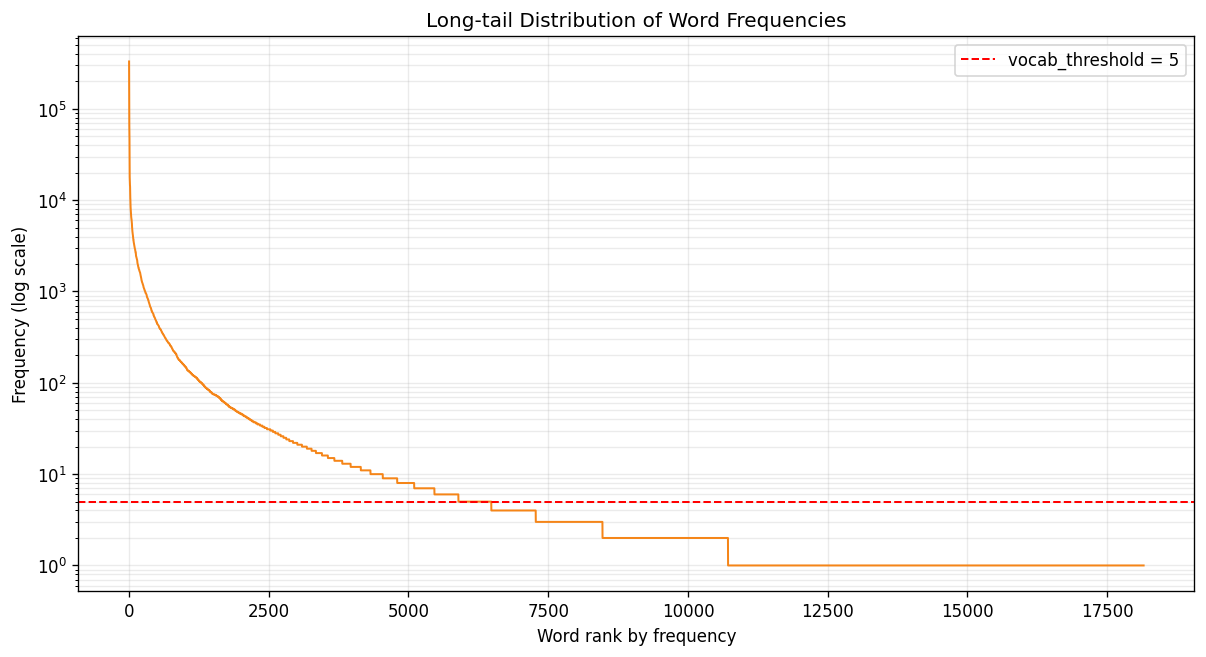

Đã lưu biểu đồ: /home/ngocanh/projects/Evaluating-the-evolution-of-Deep-Learning-architecture-in-the-Image-Captioning-problem/images/long_tail_word_frequency.png


In [86]:
ranked_frequencies = sorted(word_counts.values(), reverse=True)
ranks = range(1, len(ranked_frequencies) + 1)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(list(ranks), ranked_frequencies, linewidth=1.2, color='#F58518')
ax.axhline(VOCAB_THRESHOLD, color='red', linestyle='--', linewidth=1.2, label=f'vocab_threshold = {VOCAB_THRESHOLD}')
ax.set_yscale('log')
ax.set_title('Long-tail Distribution of Word Frequencies')
ax.set_xlabel('Word rank by frequency')
ax.set_ylabel('Frequency (log scale)')
ax.legend()
ax.grid(True, which='both', alpha=0.25)

path = save_figure(fig, 'long_tail_word_frequency.png')
plt.show()
print(f'Đã lưu biểu đồ: {path}')


**Nhận xét:**
* **Đặc trưng đuôi dài rõ rệt (Luật Zipf):** Một số lượng rất nhỏ các từ (xếp hạng đầu) có tần suất xuất hiện cực kỳ cao (vượt mức $10^4$ đến $10^5$ lần trên thang log). Ngược lại, phần lớn các từ còn lại (từ hạng 2,500 trở đi) có tần suất giảm mạnh và kéo dài thành một cái "đuôi" rất thấp.
* **Ý nghĩa của ngưỡng lọc (vocab_threshold = 5):** Đường nét đứt màu đỏ thể hiện ranh giới lọc từ. Việc đặt ngưỡng bằng 5 giúp loại bỏ toàn bộ các từ hiếm gặp (xuất hiện dưới 5 lần, nằm ở nửa cuối của đuôi đồ thị, từ khoảng hạng 6,000 trở đi).
* **Hiệu quả xử lý:** Việc loại bỏ phần đuôi dài này giúp thu gọn kích thước từ điển một cách hiệu quả, tránh cho mô hình bị nhiễu bởi các từ quá hiếm (outliers) mà vẫn giữ lại được những từ có giá trị học tập cao nhất.

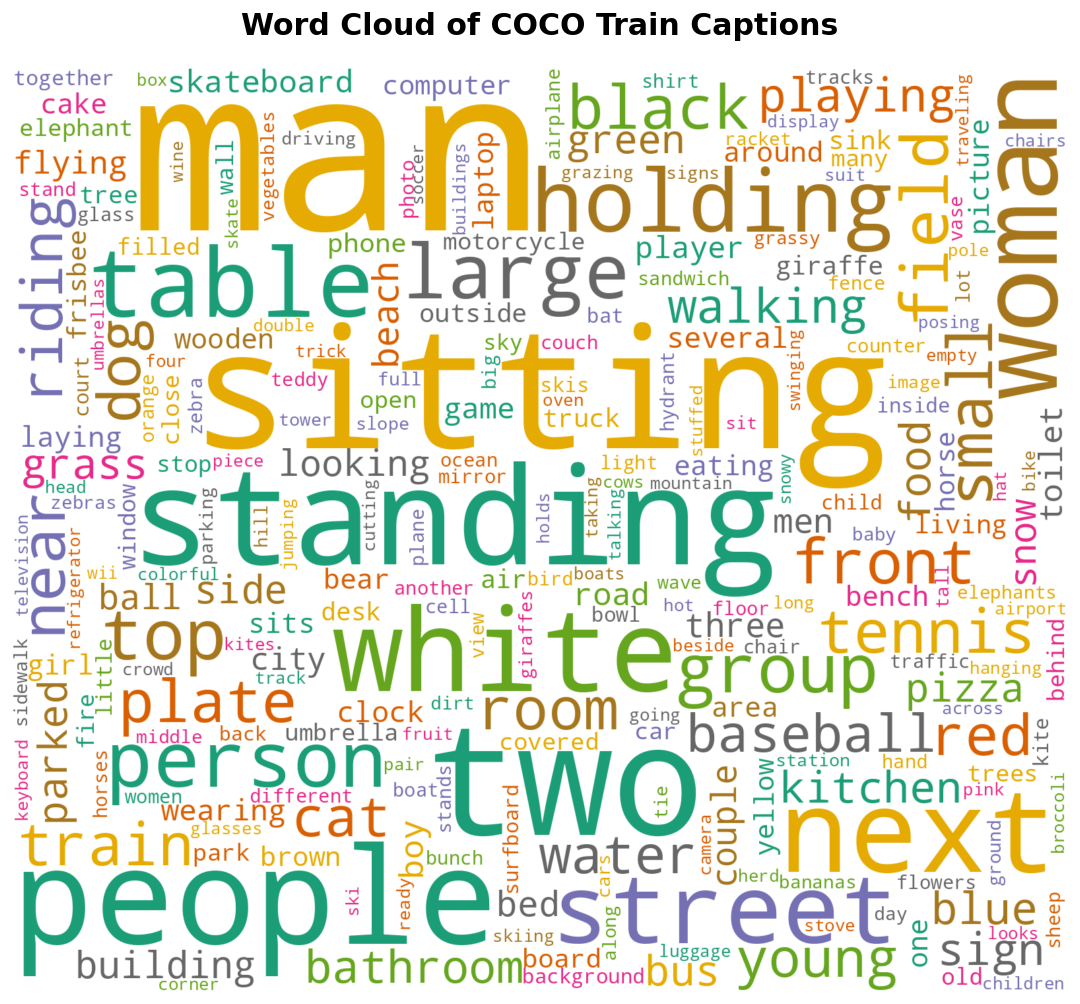

Đã lưu biểu đồ: /home/ngocanh/projects/Evaluating-the-evolution-of-Deep-Learning-architecture-in-the-Image-Captioning-problem/images/wordcloud_train_captions.png


In [87]:
wordcloud = WordCloud(
    width=1600,
    height=1400,
    background_color='white',
    colormap='Dark2',
    max_words=250,
    collocations=False,
    random_state=42,
    prefer_horizontal=0.7,
    relative_scaling=1.0,
    max_font_size=350,
    margin=2,
).generate_from_frequencies(content_word_counts)

fig, ax = plt.subplots(figsize=(14, 10), facecolor='white')
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title('Word Cloud of COCO Train Captions', fontsize=18, fontweight='bold', color='black', pad=20)

path = save_figure(fig, 'wordcloud_train_captions.png')
plt.show()
print(f'Đã lưu biểu đồ: {path}')


**Nhận xét:**
Word cloud biểu diễn tần suất xuất hiện của các từ khóa trong tập dữ liệu COCO Train Captions:

* **Chủ thể con người là trung tâm:** Các danh từ chỉ người như **"man"** (đàn ông), **"people"** (mọi người), **"person"** (người) và **"woman"** (phụ nữ) xuất hiện với kích thước khổng lồ, chứng tỏ con người là đối tượng được mô tả nhiều nhất trong các bức ảnh.
* **Hành động và Trạng thái phổ biến:** Tập dữ liệu tập trung mạnh vào các hành động quen thuộc hằng ngày với sự thống trị của ba động từ lớn: **"sitting"** (đang ngồi), **"standing"** (đang đứng) và **"holding"** (đang cầm/nắm).
* **Bối cảnh và Thực thể đi kèm:** Các từ chỉ số lượng (**"two"**), màu sắc/tính chất (**"white", "large"**) cùng bối cảnh đường phố, đời sống (**"street", "table", "group", "next"**) cấu thành những thành phần bổ trợ xuất hiện thường xuyên nhất trong các câu caption.

**Kết luận:** Tập dữ liệu COCO Train chủ yếu xoay quanh các bức ảnh chụp con người phối hợp với các hành động cơ bản và đồ vật trong không gian sinh hoạt hoặc đường phố thường nhật.


## Phase 2: Gender & Context Bias

Kiểm tra các keyword giới tính và các từ ngữ cảnh đồng xuất hiện trong cùng caption.


### Tạo nhóm từ khóa giới tính


In [88]:
MALE_WORDS = {'man', 'men', 'boy', 'boys', 'male', 'guy', 'guys', 'he'}
FEMALE_WORDS = {'woman', 'women', 'girl', 'girls', 'female', 'lady', 'ladies', 'she'}
ALL_GENDER_WORDS = MALE_WORDS | FEMALE_WORDS

print('Nhóm từ khóa Nam:')
print(', '.join(sorted(MALE_WORDS)))
print('Nhóm từ khóa Nữ:')
print(', '.join(sorted(FEMALE_WORDS)))


Nhóm từ khóa Nam:
boy, boys, guy, guys, he, male, man, men
Nhóm từ khóa Nữ:
female, girl, girls, ladies, lady, she, woman, women


### Co-occurrence giữa gender keywords và ngữ cảnh


In [89]:
for package in ('averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng'):
    try:
        nltk.download(package, quiet=True)
    except Exception as exc:
        print(f'Không thể tải NLTK package {package}: {exc}')

try:
    nltk.pos_tag(['test'])
    POS_TAG_AVAILABLE = True
except Exception as exc:
    POS_TAG_AVAILABLE = False
    print(f'POS tagging không khả dụng, sẽ dùng context words không tách POS. Lý do: {exc}')


def classify_gender_tokens(tokens):
    token_set = set(tokens)
    has_male = bool(token_set & MALE_WORDS)
    has_female = bool(token_set & FEMALE_WORDS)
    if has_male and has_female:
        return 'both'
    if has_male:
        return 'male'
    if has_female:
        return 'female'
    return 'neutral_unknown'


def get_context_words(tokens):
    return [token for token in tokens if is_content_word(token) and token not in ALL_GENDER_WORDS]


def split_nouns_verbs(context_words):
    if not POS_TAG_AVAILABLE or not context_words:
        return [], []
    try:
        tagged_words = nltk.pos_tag(context_words)
    except Exception:
        return [], []
    nouns = [word for word, tag in tagged_words if tag.startswith('NN')]
    verbs = [word for word, tag in tagged_words if tag.startswith('VB')]
    return nouns, verbs


male_context_counts = Counter()
female_context_counts = Counter()
male_noun_counts = Counter()
female_noun_counts = Counter()
male_verb_counts = Counter()
female_verb_counts = Counter()
gender_caption_counts = Counter()

for idx, ann in enumerate(train_annotations, start=1):
    tokens = tokenize_caption(ann.get('caption', ''))
    gender_label = classify_gender_tokens(tokens)
    gender_caption_counts[gender_label] += 1

    if gender_label not in {'male', 'female', 'both'}:
        continue

    context_words = sorted(set(get_context_words(tokens)))
    nouns, verbs = split_nouns_verbs(context_words)

    if gender_label in {'male', 'both'}:
        male_context_counts.update(context_words)
        male_noun_counts.update(set(nouns))
        male_verb_counts.update(set(verbs))
    if gender_label in {'female', 'both'}:
        female_context_counts.update(context_words)
        female_noun_counts.update(set(nouns))
        female_verb_counts.update(set(verbs))

    if idx % 100_000 == 0:
        print(f'Đã xử lý co-occurrence {idx:,}/{len(train_annotations):,} captions')

male_caption_count = gender_caption_counts['male'] + gender_caption_counts['both']
female_caption_count = gender_caption_counts['female'] + gender_caption_counts['both']
combined_context_counts = male_context_counts + female_context_counts
phase2_context_candidates = {word for word, _ in combined_context_counts.most_common(TOP_CONTEXT_N)}

print('Tổng quan caption theo nhóm keyword:')
print_table(
    [
        ('Chỉ có male keywords', f"{gender_caption_counts['male']:,}"),
        ('Chỉ có female keywords', f"{gender_caption_counts['female']:,}"),
        ('Có cả male và female keywords', f"{gender_caption_counts['both']:,}"),
        ('Không có gender keywords', f"{gender_caption_counts['neutral_unknown']:,}"),
        ('Tổng caption dùng cho nhóm Nam', f'{male_caption_count:,}'),
        ('Tổng caption dùng cho nhóm Nữ', f'{female_caption_count:,}'),
    ],
    headers=('Nhóm', 'Số caption'),
)

print('Top 20 context words đồng xuất hiện với nhóm Nam:')
print_table(
    [(word, f'{count:,}', f'{count / max(male_caption_count, 1) * 1000:.2f}') for word, count in male_context_counts.most_common(20)],
    headers=('Word', 'Caption count', 'Per 1,000 captions'),
)

print('Top 20 context words đồng xuất hiện với nhóm Nữ:')
print_table(
    [(word, f'{count:,}', f'{count / max(female_caption_count, 1) * 1000:.2f}') for word, count in female_context_counts.most_common(20)],
    headers=('Word', 'Caption count', 'Per 1,000 captions'),
)

if POS_TAG_AVAILABLE:
    print('Top nouns/objects - Nam:')
    print_table([(word, f'{count:,}') for word, count in male_noun_counts.most_common(15)], headers=('Noun', 'Caption count'))
    print('Top nouns/objects - Nữ:')
    print_table([(word, f'{count:,}') for word, count in female_noun_counts.most_common(15)], headers=('Noun', 'Caption count'))
    print('Top verbs/actions - Nam:')
    print_table([(word, f'{count:,}') for word, count in male_verb_counts.most_common(15)], headers=('Verb', 'Caption count'))
    print('Top verbs/actions - Nữ:')
    print_table([(word, f'{count:,}') for word, count in female_verb_counts.most_common(15)], headers=('Verb', 'Caption count'))
else:
    print('POS tagging không khả dụng nên notebook chỉ dùng context words tổng quát, chưa tách nouns/verbs.')


Đã xử lý co-occurrence 100,000/200,106 captions
Tổng quan caption theo nhóm keyword:
Nhóm                           | Số caption
-------------------------------+-----------
Chỉ có male keywords           | 31,349    
Chỉ có female keywords         | 15,594    
Có cả male và female keywords  | 2,828     
Không có gender keywords       | 150,335   
Tổng caption dùng cho nhóm Nam | 34,177    
Tổng caption dùng cho nhóm Nữ  | 18,422    
Top 20 context words đồng xuất hiện với nhóm Nam:
Word       | Caption count | Per 1,000 captions
-----------+---------------+-------------------
standing   | 3,783         | 110.69            
holding    | 3,725         | 108.99            
young      | 2,940         | 86.02             
two        | 2,822         | 82.57             
sitting    | 2,728         | 79.82             
riding     | 2,709         | 79.26             
skateboard | 2,274         | 66.54             
playing    | 2,056         | 60.16             
tennis     | 2,034         | 59.5

**Nhận xét:**
Các bảng co-occurrence cho thấy những từ ngữ cảnh đi cùng keyword giới tính không hoàn toàn giống nhau giữa hai nhóm. Vì đây là thống kê đồng xuất hiện trong caption, kết quả chỉ nên được hiểu là dấu hiệu bias tiềm năng chứ chưa phải kết luận nhân quả.


### Trực quan hóa


**Heatmap co-occurrence Nam/Nữ**

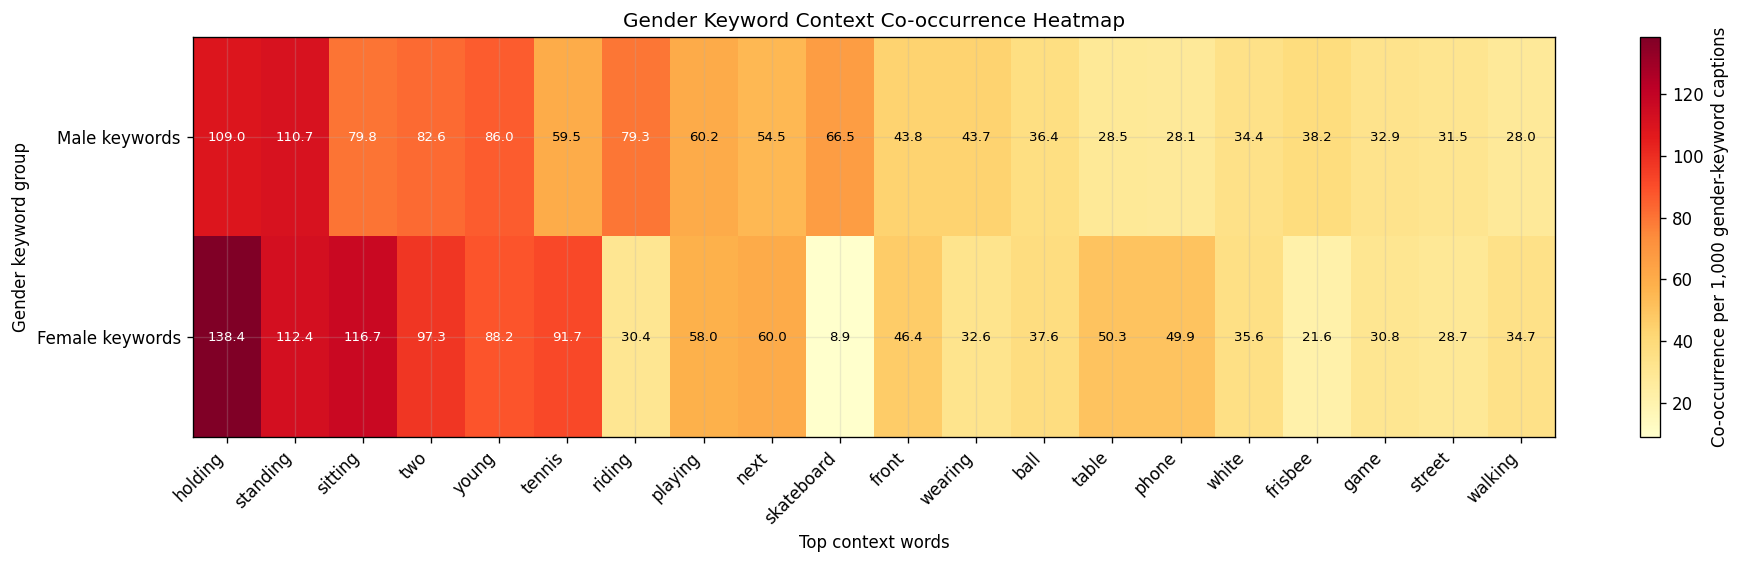

Đã lưu biểu đồ: /home/ngocanh/projects/Evaluating-the-evolution-of-Deep-Learning-architecture-in-the-Image-Captioning-problem/images/gender_context_heatmap.png


In [90]:
heatmap_terms = [word for word, _ in combined_context_counts.most_common(TOP_CONTEXT_N)]
heatmap_values = [
    [male_context_counts[word] / max(male_caption_count, 1) * 1000 for word in heatmap_terms],
    [female_context_counts[word] / max(female_caption_count, 1) * 1000 for word in heatmap_terms],
]

fig, ax = plt.subplots(figsize=(16, 4.8))
im = ax.imshow(heatmap_values, cmap='YlOrRd', aspect='auto')
ax.set_title('Gender Keyword Context Co-occurrence Heatmap')
ax.set_yticks([0, 1])
ax.set_yticklabels(['Male keywords', 'Female keywords'])
ax.set_xticks(range(len(heatmap_terms)))
ax.set_xticklabels(heatmap_terms, rotation=45, ha='right')
ax.set_ylabel('Gender keyword group')
ax.set_xlabel('Top context words')

max_value = max([max(row) for row in heatmap_values]) if heatmap_terms else 0
for row_idx, row in enumerate(heatmap_values):
    for col_idx, value in enumerate(row):
        text_color = 'white' if max_value and value > max_value * 0.55 else 'black'
        ax.text(col_idx, row_idx, f'{value:.1f}', ha='center', va='center', fontsize=8, color=text_color)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Co-occurrence per 1,000 gender-keyword captions')
fig.tight_layout()

path = save_figure(fig, 'gender_context_heatmap.png')
plt.show()
print(f'Đã lưu biểu đồ: {path}')


**Nhận xét:**
Heatmap cho thấy sự **định kiến giới tính (gender bias) rõ rệt** trong tập dữ liệu: 

* **Điểm chung:** Các hành động cơ bản như *"holding"* và *"standing"* xuất hiện dày đặc ở cả hai giới (đều > 100).
* **Thiên lệch về Nam giới:** Gắn liền vượt trội với các hoạt động thể thao, vận động mạnh như **"skateboard"** (66.5 so với 8.9) hoặc **"riding"** (59.5 so với 30.4).
* **Thiên lệch về Nữ giới:** Xuất hiện nhiều hơn ở các trạng thái tĩnh hoặc bối cảnh trong nhà, giao tiếp như **"sitting"** (116.7 so với 79.8), **"tennis"**, **"table"** và **"phone"**.


**Venn diagram của các từ ngữ cảnh nổi bật**


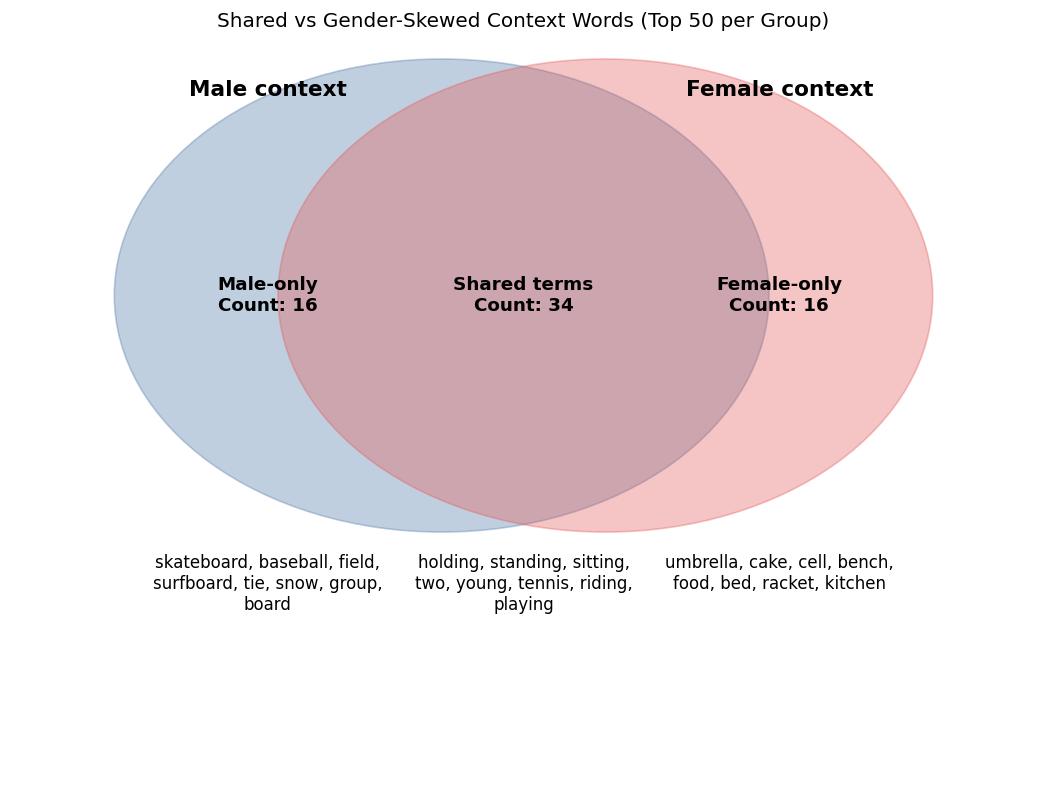

Đã lưu biểu đồ: /home/ngocanh/projects/Evaluating-the-evolution-of-Deep-Learning-architecture-in-the-Image-Captioning-problem/images/gender_context_venn.png


In [91]:
male_top_terms = {word for word, _ in male_context_counts.most_common(50)}
female_top_terms = {word for word, _ in female_context_counts.most_common(50)}
shared_terms = male_top_terms & female_top_terms
male_only_terms = male_top_terms - female_top_terms
female_only_terms = female_top_terms - male_top_terms


def format_examples(terms, counter, limit=8):
    ordered = sorted(terms, key=lambda word: counter[word], reverse=True)
    return ', '.join(ordered[:limit]) if ordered else 'Không có'

fig, ax = plt.subplots(figsize=(11, 8))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('Shared vs Gender-Skewed Context Words (Top 50 per Group)')

male_circle = Circle((0.42, 0.65), 0.32, color='#4C78A8', alpha=0.35)
female_circle = Circle((0.58, 0.65), 0.32, color='#E45756', alpha=0.35)
ax.add_patch(male_circle)
ax.add_patch(female_circle)

ax.text(0.25, 0.92, 'Male context', ha='center', fontsize=13, weight='bold')
ax.text(0.75, 0.92, 'Female context', ha='center', fontsize=13, weight='bold')

ax.text(0.25, 0.65, f"Male-only\nCount: {len(male_only_terms)}", ha='center', va='center', fontsize=11, weight='bold')
ax.text(0.50, 0.65, f"Shared terms\nCount: {len(shared_terms)}", ha='center', va='center', fontsize=11, weight='bold')
ax.text(0.75, 0.65, f"Female-only\nCount: {len(female_only_terms)}", ha='center', va='center', fontsize=11, weight='bold')

ax.text(0.25, 0.30, fill(format_examples(male_only_terms, male_context_counts), 32), ha='center', va='top', fontsize=10)
ax.text(0.50, 0.30, fill(format_examples(shared_terms, combined_context_counts), 28), ha='center', va='top', fontsize=10)
ax.text(0.75, 0.30, fill(format_examples(female_only_terms, female_context_counts), 32), ha='center', va='top', fontsize=10)

path = save_figure(fig, 'gender_context_venn.png')
plt.show()
print(f'Đã lưu biểu đồ: {path}')


**Nhận xét:**
Venn diagram thể hiện sự giao thoa và tách biệt trong bối cảnh từ ngữ giữa hai giới (Top 50 từ mỗi nhóm):

* **Điểm chung (Shared terms - 34 từ):** Chiếm đa số, bao gồm các hành động và mô tả trung tính như *"holding", "standing", "sitting", "young", "playing"*.
* **Đặc trưng Nam giới (Male-only - 16 từ):** Tập trung mạnh vào thể thao ngoài trời và hành động mạo hiểm như **"skateboard", "baseball", "surfboard", "field", "snow"**.
* **Đặc trưng Nữ giới (Female-only - 16 từ):** Gắn liền với không gian sinh hoạt, đồ ăn và đồ gia dụng như **"kitchen", "cake", "food", "bed", "umbrella"**.

**Kết luận:** Dù chia sẻ chung phần lớn từ vựng mô tả cơ bản, tập dữ liệu vẫn phản ánh rõ xu hướng phân hóa định kiến: Nam giới hướng về thể thao/dã ngoại, Nữ giới hướng về nội trợ/đời sống hằng ngày.


## Phase 3: Amplification Bias


### Chạy mô hình trên tập Test để lấy toàn bộ Caption dự đoán.

In [92]:
MODEL_CONFIGS = {name: load_config(str(path)) for name, path in MODEL_CONFIG_PATHS.items()}
MODEL_TYPES = {
    'baseline_lstm': 'lstm',
    'm2_transformer': 'm2_transformer',
    'vit_transformer': 'vit_transformer',
}


def load_model_bundle(model_name, vocab, device):
    config = MODEL_CONFIGS[model_name]
    checkpoint_path = MODEL_CHECKPOINTS[model_name]
    checkpoint = torch.load(checkpoint_path, map_location=device)

    if model_name == 'baseline_lstm':
        encoder = ResNet50Encoder(config['model']['embed_size'])
        decoder = LSTMDecoder(
            config['model']['embed_size'],
            config['model']['hidden_size'],
            len(vocab),
            config['model']['num_layers'],
        )
        encoder.load_state_dict(checkpoint['encoder_state_dict'])
        decoder.load_state_dict(checkpoint['decoder_state_dict'])
        return encoder.to(device).eval(), decoder.to(device).eval()

    if model_name == 'm2_transformer':
        encoder = ResNet50SpatialEncoder(config['model']['embed_size'])
        decoder = M2TransformerDecoder(
            len(vocab),
            config['model']['embed_size'],
            config['model']['num_heads'],
            config['model']['num_layers'],
            config['model']['max_seq_len'],
        )
        encoder.load_state_dict(checkpoint['encoder_state_dict'])
        decoder.load_state_dict(checkpoint['decoder_state_dict'])
        return encoder.to(device).eval(), decoder.to(device).eval()

    if model_name == 'vit_transformer':
        encoder = nn.Identity()
        decoder = ViTCaptioningModel(
            len(vocab),
            config['model']['embed_size'],
            config['model']['num_heads'],
            config['model']['num_layers'],
        )
        decoder.load_state_dict(checkpoint['decoder_state_dict'])
        return encoder.to(device).eval(), decoder.to(device).eval()

    raise ValueError(f'Không hỗ trợ model_name={model_name}')


def load_or_run_predictions(model_name, vocab, image_ids, image_id_to_file, ground_truths, image_root, device):
    cache_path = CACHE_DIR / f'{model_name}_predictions.json'
    if cache_path.exists():
        return load_json(cache_path), cache_path, []

    encoder, decoder = load_model_bundle(model_name, vocab, device)
    model_type = MODEL_TYPES[model_name]
    predictions = []
    missing_images = []

    print(f'Đang chạy inference cho {model_name} trên {len(image_ids):,} ảnh...')
    for idx, image_id in enumerate(image_ids, start=1):
        file_name = image_id_to_file.get(image_id)
        if not file_name:
            continue

        image_path = image_root / file_name
        if not image_path.exists():
            missing_images.append(str(image_path))
            continue

        predicted_caption, _ = generate_caption(
            str(image_path),
            encoder,
            decoder,
            vocab,
            device,
            model_type=model_type,
            mode='greedy',
        )
        predictions.append(
            {
                'image_id': image_id,
                'image_path': str(image_path),
                'ground_truth_captions': ground_truths[image_id],
                'prediction': predicted_caption,
            }
        )

        if idx % 500 == 0:
            print(f'  {model_name}: {idx:,}/{len(image_ids):,} images')

    with cache_path.open('w', encoding='utf-8') as f:
        json.dump(predictions, f, ensure_ascii=False, indent=2)

    del encoder, decoder
    gc.collect()
    if device.type == 'cuda':
        torch.cuda.empty_cache()

    return predictions, cache_path, missing_images


def preview_prediction_rows(predictions, limit=5):
    rows = []
    for record in predictions[:limit]:
        gt_preview = shorten(' | '.join(normalize_text_list(record.get('ground_truth_captions', []))), width=75, placeholder='...')
        pred_preview = shorten(str(record.get('prediction', '')), width=75, placeholder='...')
        rows.append((record.get('image_id', 'unknown'), gt_preview, pred_preview))
    return rows


def enrich_prediction_records(records):
    enriched = []
    for record in records:
        gt_label = gender_label_from_texts(record.get('ground_truth_captions', []))
        pred_label = gender_label_from_texts(record.get('prediction', ''))
        token_pool = set()
        for text in normalize_text_list(record.get('ground_truth_captions', [])):
            token_pool.update(tokenize_caption(text))
        token_pool.update(tokenize_caption(record.get('prediction', '')))
        suspect_terms = sorted(token_pool & phase2_context_candidates)
        enriched.append({**record, 'gt_label': gt_label, 'pred_label': pred_label, 'suspect_terms': suspect_terms})
    return enriched


[*] Đã nạp cấu hình từ /home/ngocanh/projects/Evaluating-the-evolution-of-Deep-Learning-architecture-in-the-Image-Captioning-problem/configs/baseline_lstm.yaml
[*] Đã nạp cấu hình từ /home/ngocanh/projects/Evaluating-the-evolution-of-Deep-Learning-architecture-in-the-Image-Captioning-problem/configs/m2_transformer.yaml
[*] Đã nạp cấu hình từ /home/ngocanh/projects/Evaluating-the-evolution-of-Deep-Learning-architecture-in-the-Image-Captioning-problem/configs/vit_transformer.yaml


In [100]:
TEST_DATA, TEST_IMAGES, TEST_ANNOTATIONS, TEST_IMAGE_ID_TO_FILE, TEST_GROUND_TRUTHS = load_coco_split(TEST_ANN_FILE)
TEST_IMAGE_IDS = sorted(TEST_GROUND_TRUTHS)

if not VOCAB_PATH.exists():
    raise FileNotFoundError(f'Không tìm thấy vocab file: {VOCAB_PATH}')

with open(VOCAB_PATH, "rb") as f:
    VOCAB = pickle.load(f)

if hasattr(VOCAB, 'word_to_idx') and not hasattr(VOCAB, 'word2idx'):
    VOCAB.word2idx = VOCAB.word_to_idx
    VOCAB.idx2word = VOCAB.idx_to_word

print(f'Số image unique trong test split: {len(TEST_IMAGE_IDS):,}')
print(f'Số annotation test: {len(TEST_ANNOTATIONS):,}')
print(f'Image root cho test split: {IMAGE_ROOT}')
print(f'Vocabulary size: {len(VOCAB):,}')

Số image unique trong test split: 5,000
Số annotation test: 25,012
Image root cho test split: /home/ngocanh/projects/Evaluating-the-evolution-of-Deep-Learning-architecture-in-the-Image-Captioning-problem/data/data/ms_coco/train2014
Vocabulary size: 8,853


#### Baseline LSTM


In [101]:
baseline_predictions, baseline_cache_path, baseline_missing_images = load_or_run_predictions(
    'baseline_lstm',
    VOCAB,
    TEST_IMAGE_IDS,
    TEST_IMAGE_ID_TO_FILE,
    TEST_GROUND_TRUTHS,
    IMAGE_ROOT,
    DEVICE,
)

print_table(
    [
        ('Model', 'baseline_lstm'),
        ('Checkpoint', str(MODEL_CHECKPOINTS['baseline_lstm'].relative_to(PROJECT_ROOT))),
        ('Prediction cache', str(baseline_cache_path.relative_to(PROJECT_ROOT))),
        ('Số prediction record', f'{len(baseline_predictions):,}'),
        ('Số ảnh thiếu file', f'{len(baseline_missing_images):,}'),
        ('Model type gửi vào generate_caption', MODEL_TYPES['baseline_lstm']),
    ],
    headers=('Chỉ số', 'Giá trị'),
)

print('Ví dụ prediction của baseline_lstm:')
print_table(preview_prediction_rows(baseline_predictions, limit=5), headers=('Image ID', 'Ground truth preview', 'Prediction preview'))


Đang chạy inference cho baseline_lstm trên 5,000 ảnh...
  baseline_lstm: 500/5,000 images
  baseline_lstm: 1,000/5,000 images
  baseline_lstm: 1,500/5,000 images
  baseline_lstm: 2,000/5,000 images
  baseline_lstm: 2,500/5,000 images
  baseline_lstm: 3,000/5,000 images
  baseline_lstm: 3,500/5,000 images
  baseline_lstm: 4,000/5,000 images
  baseline_lstm: 4,500/5,000 images
  baseline_lstm: 5,000/5,000 images
Chỉ số                              | Giá trị                                                              
------------------------------------+----------------------------------------------------------------------
Model                               | baseline_lstm                                                        
Checkpoint                          | experiments/experiments/checkpoints/baseline_lstm_run1/best_model.pth
Prediction cache                    | analysis_cache/baseline_lstm_predictions.json                        
Số prediction record                | 5,000   

In [102]:
checkpoint = torch.load(
    MODEL_CHECKPOINTS['baseline_lstm'],
    map_location='cpu'
)

print(checkpoint.keys())

dict_keys(['epoch', 'encoder_state_dict', 'decoder_state_dict', 'optimizer_state_dict', 'val_loss'])


#### M2 Transformer


In [103]:
m2_predictions, m2_cache_path, m2_missing_images = load_or_run_predictions(
    'm2_transformer',
    VOCAB,
    TEST_IMAGE_IDS,
    TEST_IMAGE_ID_TO_FILE,
    TEST_GROUND_TRUTHS,
    IMAGE_ROOT,
    DEVICE,
)

print_table(
    [
        ('Model', 'm2_transformer'),
        ('Checkpoint', str(MODEL_CHECKPOINTS['m2_transformer'].relative_to(PROJECT_ROOT))),
        ('Prediction cache', str(m2_cache_path.relative_to(PROJECT_ROOT))),
        ('Số prediction record', f'{len(m2_predictions):,}'),
        ('Số ảnh thiếu file', f'{len(m2_missing_images):,}'),
        ('Model type gửi vào generate_caption', MODEL_TYPES['m2_transformer']),
    ],
    headers=('Chỉ số', 'Giá trị'),
)

print('Ví dụ prediction của m2_transformer:')
print_table(preview_prediction_rows(m2_predictions, limit=5), headers=('Image ID', 'Ground truth preview', 'Prediction preview'))


Đang chạy inference cho m2_transformer trên 5,000 ảnh...
  m2_transformer: 500/5,000 images
  m2_transformer: 1,000/5,000 images
  m2_transformer: 1,500/5,000 images
  m2_transformer: 2,000/5,000 images
  m2_transformer: 2,500/5,000 images
  m2_transformer: 3,000/5,000 images
  m2_transformer: 3,500/5,000 images
  m2_transformer: 4,000/5,000 images
  m2_transformer: 4,500/5,000 images
  m2_transformer: 5,000/5,000 images
Chỉ số                              | Giá trị                                                               
------------------------------------+-----------------------------------------------------------------------
Model                               | m2_transformer                                                        
Checkpoint                          | experiments/experiments/checkpoints/m2_transformer_run1/best_model.pth
Prediction cache                    | analysis_cache/m2_transformer_predictions.json                        
Số prediction record          

#### ViT Transformer


In [104]:
vit_predictions, vit_cache_path, vit_missing_images = load_or_run_predictions(
    'vit_transformer',
    VOCAB,
    TEST_IMAGE_IDS,
    TEST_IMAGE_ID_TO_FILE,
    TEST_GROUND_TRUTHS,
    IMAGE_ROOT,
    DEVICE,
)

print_table(
    [
        ('Model', 'vit_transformer'),
        ('Checkpoint', str(MODEL_CHECKPOINTS['vit_transformer'].relative_to(PROJECT_ROOT))),
        ('Prediction cache', str(vit_cache_path.relative_to(PROJECT_ROOT))),
        ('Số prediction record', f'{len(vit_predictions):,}'),
        ('Số ảnh thiếu file', f'{len(vit_missing_images):,}'),
        ('Model type gửi vào generate_caption', MODEL_TYPES['vit_transformer']),
    ],
    headers=('Chỉ số', 'Giá trị'),
)

print('Ví dụ prediction của vit_transformer:')
print_table(preview_prediction_rows(vit_predictions, limit=5), headers=('Image ID', 'Ground truth preview', 'Prediction preview'))


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /home/ngocanh/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:30<00:00, 11.3MB/s] 


Đang chạy inference cho vit_transformer trên 5,000 ảnh...
  vit_transformer: 500/5,000 images
  vit_transformer: 1,000/5,000 images
  vit_transformer: 1,500/5,000 images
  vit_transformer: 2,000/5,000 images
  vit_transformer: 2,500/5,000 images
  vit_transformer: 3,000/5,000 images
  vit_transformer: 3,500/5,000 images
  vit_transformer: 4,000/5,000 images
  vit_transformer: 4,500/5,000 images
  vit_transformer: 5,000/5,000 images
Chỉ số                              | Giá trị                                                              
------------------------------------+----------------------------------------------------------------------
Model                               | vit_transformer                                                      
Checkpoint                          | experiments/experiments/checkpoints/vit_transformer_v1/best_model.pth
Prediction cache                    | analysis_cache/vit_transformer_predictions.json                      
Số prediction record    

### Tìm các trường hợp Mô hình đoán sai giới tính hoặc vật thể do bối cảnh.

In [119]:
MALE_BIASED_CONTEXTS = ['skateboard', 'baseball', 'surfboard', 'field', 'snow', 'snowboard', 'riding', 'playing']
FEMALE_BIASED_CONTEXTS = ['kitchen', 'cake', 'food', 'bed', 'umbrella', 'table', 'phone', 'sitting']

print("===== CÁC TRƯỜNG HỢP MÔ HÌNH BỊ BỐI CẢNH ĐÁNH LỪA (CONTEXT BIAS) =====")

# Duyệt qua từng mô hình
for model_name, records in phase3_model_predictions.items():
    print(f"\n[MÔ HÌNH]: {model_name.upper()}")
    print("-" * 70)
    
    bias_cases_count = 0
    
    for record in records:
        # SỬA TẠI ĐÂY: Thêm .lower() để ép nhãn về chữ thường, tránh lỗi 'Male' != 'male'
        gt = str(record['gt_label']).lower()
        pred = str(record['pred_label']).lower()
        caption = record['prediction'].lower()
        
        triggered_context = None
        bias_type = None
        
        # TRƯỜNG HỢP A: Thực tế là NỮ nhưng mô hình đoán thành NAM do dính bối cảnh của NAM
        if gt == 'female' and pred == 'male':
            for word in MALE_BIASED_CONTEXTS:
                if word in caption:
                    triggered_context = word
                    bias_type = "Thực tế là NỮ -> đoán nhầm thành NAM (Bị lừa bởi bối cảnh hoạt động của Nam)"
                    break
                    
        # TRƯỜNG HỢP B: Thực tế là NAM nhưng mô hình đoán thành NỮ do dính bối cảnh của NỮ
        elif gt == 'male' and pred == 'female':
            for word in FEMALE_BIASED_CONTEXTS:
                if word in caption:
                    triggered_context = word
                    bias_type = "Thực tế là NAM -> đoán nhầm thành NỮ (Bị lừa bởi bối cảnh hoạt động của Nữ)"
                    break

        # Nếu phát hiện ca bị lừa bởi bối cảnh, in ra chi tiết để phân tích
        if triggered_context:
            bias_cases_count += 1
            if bias_cases_count <= 3:
                print(f"\n[Ví dụ {bias_cases_count}] Image ID: {record['image_id']}")
                print(f"  ▪️ Loại lỗi: {bias_type}")
                print(f"  ▪️ Từ bối cảnh gây nhiễu: '{triggered_context}'")
                print(f"  ▪️ Ground Truth Captions (Gốc):")
                for gt_cap in record['ground_truth_captions'][:2]:
                    print(f"      - {gt_cap}")
                print(f"  ▪️ Mô hình dự đoán sai: \"{record['prediction']}\"")
                
print(f"\n=> Tổng số ca phát hiện bị dính Context Bias ở {model_name}: {bias_cases_count} trường hợp.")
print("=" * 70)

===== CÁC TRƯỜNG HỢP MÔ HÌNH BỊ BỐI CẢNH ĐÁNH LỪA (CONTEXT BIAS) =====

[MÔ HÌNH]: BASELINE_LSTM
----------------------------------------------------------------------

[Ví dụ 1] Image ID: 6409
  ▪️ Loại lỗi: Thực tế là NAM -> đoán nhầm thành NỮ (Bị lừa bởi bối cảnh hoạt động của Nữ)
  ▪️ Từ bối cảnh gây nhiễu: 'sitting'
  ▪️ Ground Truth Captions (Gốc):
      - A man doing skateboard tricks in a small yard
      - A man is by himself outside on his skateboard.
  ▪️ Mô hình dự đoán sai: "a woman sitting on a bench in front of a building ."

[Ví dụ 2] Image ID: 8186
  ▪️ Loại lỗi: Thực tế là NAM -> đoán nhầm thành NỮ (Bị lừa bởi bối cảnh hoạt động của Nữ)
  ▪️ Từ bối cảnh gây nhiễu: 'sitting'
  ▪️ Ground Truth Captions (Gốc):
      - A person stands on a snowboard on top of a tarp.
      - Someone on a snow board while on a blanket near the woods
  ▪️ Mô hình dự đoán sai: "a woman is sitting on a bench in the park ."

[Ví dụ 3] Image ID: 9771
  ▪️ Loại lỗi: Thực tế là NỮ -> đoán nhầm th

### Trực quan hóa

**Confustion Matrix**

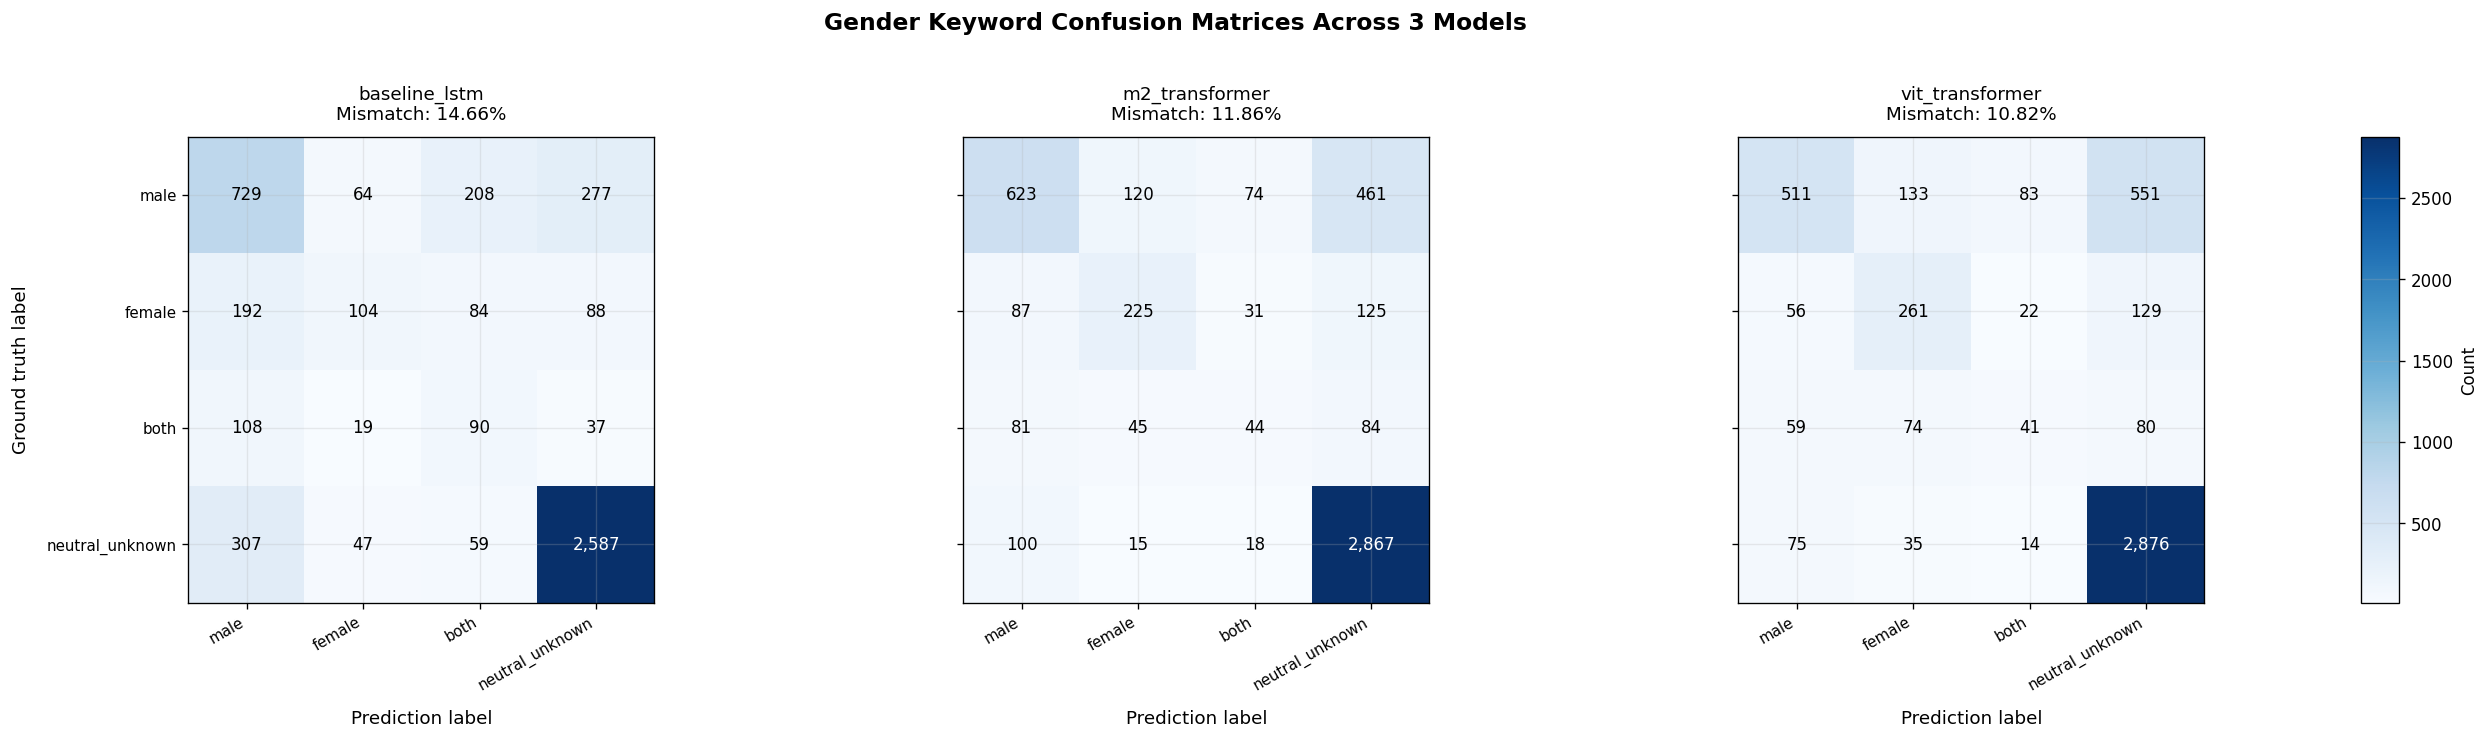

Đã lưu biểu đồ: /home/ngocanh/projects/Evaluating-the-evolution-of-Deep-Learning-architecture-in-the-Image-Captioning-problem/images/gender_confusion_matrix_3_models.png


In [121]:
phase3_confusion_matrices = {}
for model_name, records in phase3_model_predictions.items():
    matrix = [[0 for _ in phase3_confusion_labels] for _ in phase3_confusion_labels]
    for record in records:
        gt_idx = phase3_label_to_idx[record['gt_label']]
        pred_idx = phase3_label_to_idx[record['pred_label']]
        matrix[gt_idx][pred_idx] += 1
    phase3_confusion_matrices[model_name] = matrix

fig, axes = plt.subplots(
    1, 4, 
    figsize=(22, 6), 
    sharex=False, sharey=False, 
    gridspec_kw={'width_ratios': [1, 1, 1, 0.05]} 
)

plot_axes = axes[:3]
cbar_ax = axes[3]

for ax, model_name in zip(plot_axes, ['baseline_lstm', 'm2_transformer', 'vit_transformer']):
    matrix = phase3_confusion_matrices[model_name]
    
    # imshow vẽ ma trận lên trục hiện tại
    im = ax.imshow(matrix, cmap='Blues')
    
    ax.set_title(f"{model_name}\nMismatch: {phase3_model_metrics[model_name]['mismatch_rate']:.2f}%", fontsize=11, pad=10)
    ax.set_xticks(range(len(phase3_confusion_labels)))
    ax.set_xticklabels(phase3_confusion_labels, rotation=30, ha='right', fontsize=9)
    ax.set_yticks(range(len(phase3_confusion_labels)))
    
    # Chỉ hiện nhãn chữ trục dọc cho ma trận đầu tiên ngoài cùng bên trái
    if ax is plot_axes[0]:
        ax.set_yticklabels(phase3_confusion_labels, fontsize=9)
        ax.set_ylabel('Ground truth label', fontsize=11, labelpad=10)
    else:
        ax.set_yticklabels([]) # 2 ma trận sau ẩn chữ đi vì chung hệ tọa độ hàng với hình 1

    ax.set_xlabel('Prediction label', fontsize=11, labelpad=10)

    # Điền số lượng vào các ô
    max_value = max(max(row) for row in matrix) if matrix else 0
    for row_idx, row in enumerate(matrix):
        for col_idx, value in enumerate(row):
            text_color = 'white' if max_value and value > max_value * 0.55 else 'black'
            ax.text(col_idx, row_idx, f"{value:,}", ha='center', va='center', color=text_color, fontsize=10)

fig.colorbar(im, cax=cbar_ax, label='Count')

fig.suptitle('Gender Keyword Confusion Matrices Across 3 Models', y=1.02, fontsize=14, fontweight='bold')

fig.tight_layout()

# Lưu và hiển thị đồ thị
path = save_figure(fig, 'gender_confusion_matrix_3_models.png')
plt.show()
print(f'Đã lưu biểu đồ: {path}')

**Nhận xét:**

Biểu đồ Confusion Matrices (Ma trận nhầm lẫn) thể hiện chi tiết cách phân loại các từ khóa giới tính của 3 mô hình trên tập Test:

**1.** Xu hướng dịch chuyển sang nhóm trung tính (Neutralization)
* Điểm chung lớn nhất của cả 3 mô hình là xu hướng dự đoán nhầm các nhãn giới tính (`male`, `female`, `both`) thành **`neutral_unknown`** (cột ngoài cùng bên phải).
* Khả năng giữ lại nhãn giới tính giảm dần từ LSTM sang ViT. Ví dụ với nhãn gốc `male`: `baseline_lstm` đoán đúng 729 mẫu, sang `m2_transformer` giảm còn 623 và `vit_transformer` chỉ còn 511, trong khi số ca bị đẩy sang `neutral_unknown` tăng mạnh tương ứng (277 $\rightarrow$ 461 $\rightarrow$ 551).
* **Ý nghĩa:** Các kiến trúc Transformer tiên tiến có xu hướng "an toàn hóa" câu dự đoán bằng cách dùng các từ trung tính (*person, people*) thay vì quy chụp giới tính, giúp làm giảm tỷ lệ mismatch tổng thể nhưng làm giảm độ chi tiết của thực thể.

**2.** Sự thay đổi trong việc nhận diện nhãn Nữ giới (Female)
* **Baseline LSTM nhận diện Nữ rất kém:** Chỉ đoán đúng 104 mẫu `female`, nhưng đoán nhầm sang `male` tận 192 mẫu (gần gấp đôi số ca đoán đúng).
* **Transformer cải thiện rõ rệt:** `m2_transformer` nâng số ca đoán đúng `female` lên 225 (nhầm sang male giảm còn 87); `vit_transformer` đạt kết quả tốt nhất khi đoán đúng 261 mẫu `female` (nhầm sang male chỉ còn 56).
* **Ý nghĩa:** Cơ chế Attention thị giác mạnh mẽ của Transformer (đặc biệt là ViT) giúp mô hình thực sự "nhìn" và phân tích được các đặc điểm của nữ giới trong ảnh tốt hơn, thay vì học vẹt theo xác suất từ vựng như LSTM.

**3.** Nhãn kết hợp (Both) và Ô dự đoán đúng cốt lõi
* Nhãn **`both`** (ảnh chứa cả nam và nữ) là nhãn khó nhất. Cả 3 mô hình đều phân loại đúng rất ít nhãn này (cao nhất là 90 ở LSTM, thấp nhất là 41 ở ViT) và hầu hết bị biến thành `male` hoặc `neutral_unknown`.
* Ô góc dưới cùng bên phải (`neutral_unknown` $\rightarrow$ `neutral_unknown`) có mật độ dày đặc nhất và tăng dần (2587 $\rightarrow$ 2867 $\rightarrow$ 2876), chứng tỏ tập dữ liệu Test chứa phần lớn các bức ảnh không có yếu tố con người hoặc bối cảnh giới tính, và các mô hình Transformer xử lý nhóm ảnh này tốt hơn, ít bị "bịa" thêm giới tính vào câu mô tả.

**Kết luận chung:** Sự cải tiến kiến trúc từ LSTM lên Transformer/ViT giúp mô hình bớt bị thiên vị một chiều sang phía Nam giới (giảm mạnh lỗi Female $\rightarrow$ Male), tuy nhiên đánh đổi lại là mô hình trở nên "thận trọng" hơn và tăng xu hướng trung tính hóa các câu mô tả.


**In ảnh cùng với Ground Truth và Prediction ra thành lưới (Grid) để làm bằng chứng (Error Analysis)**

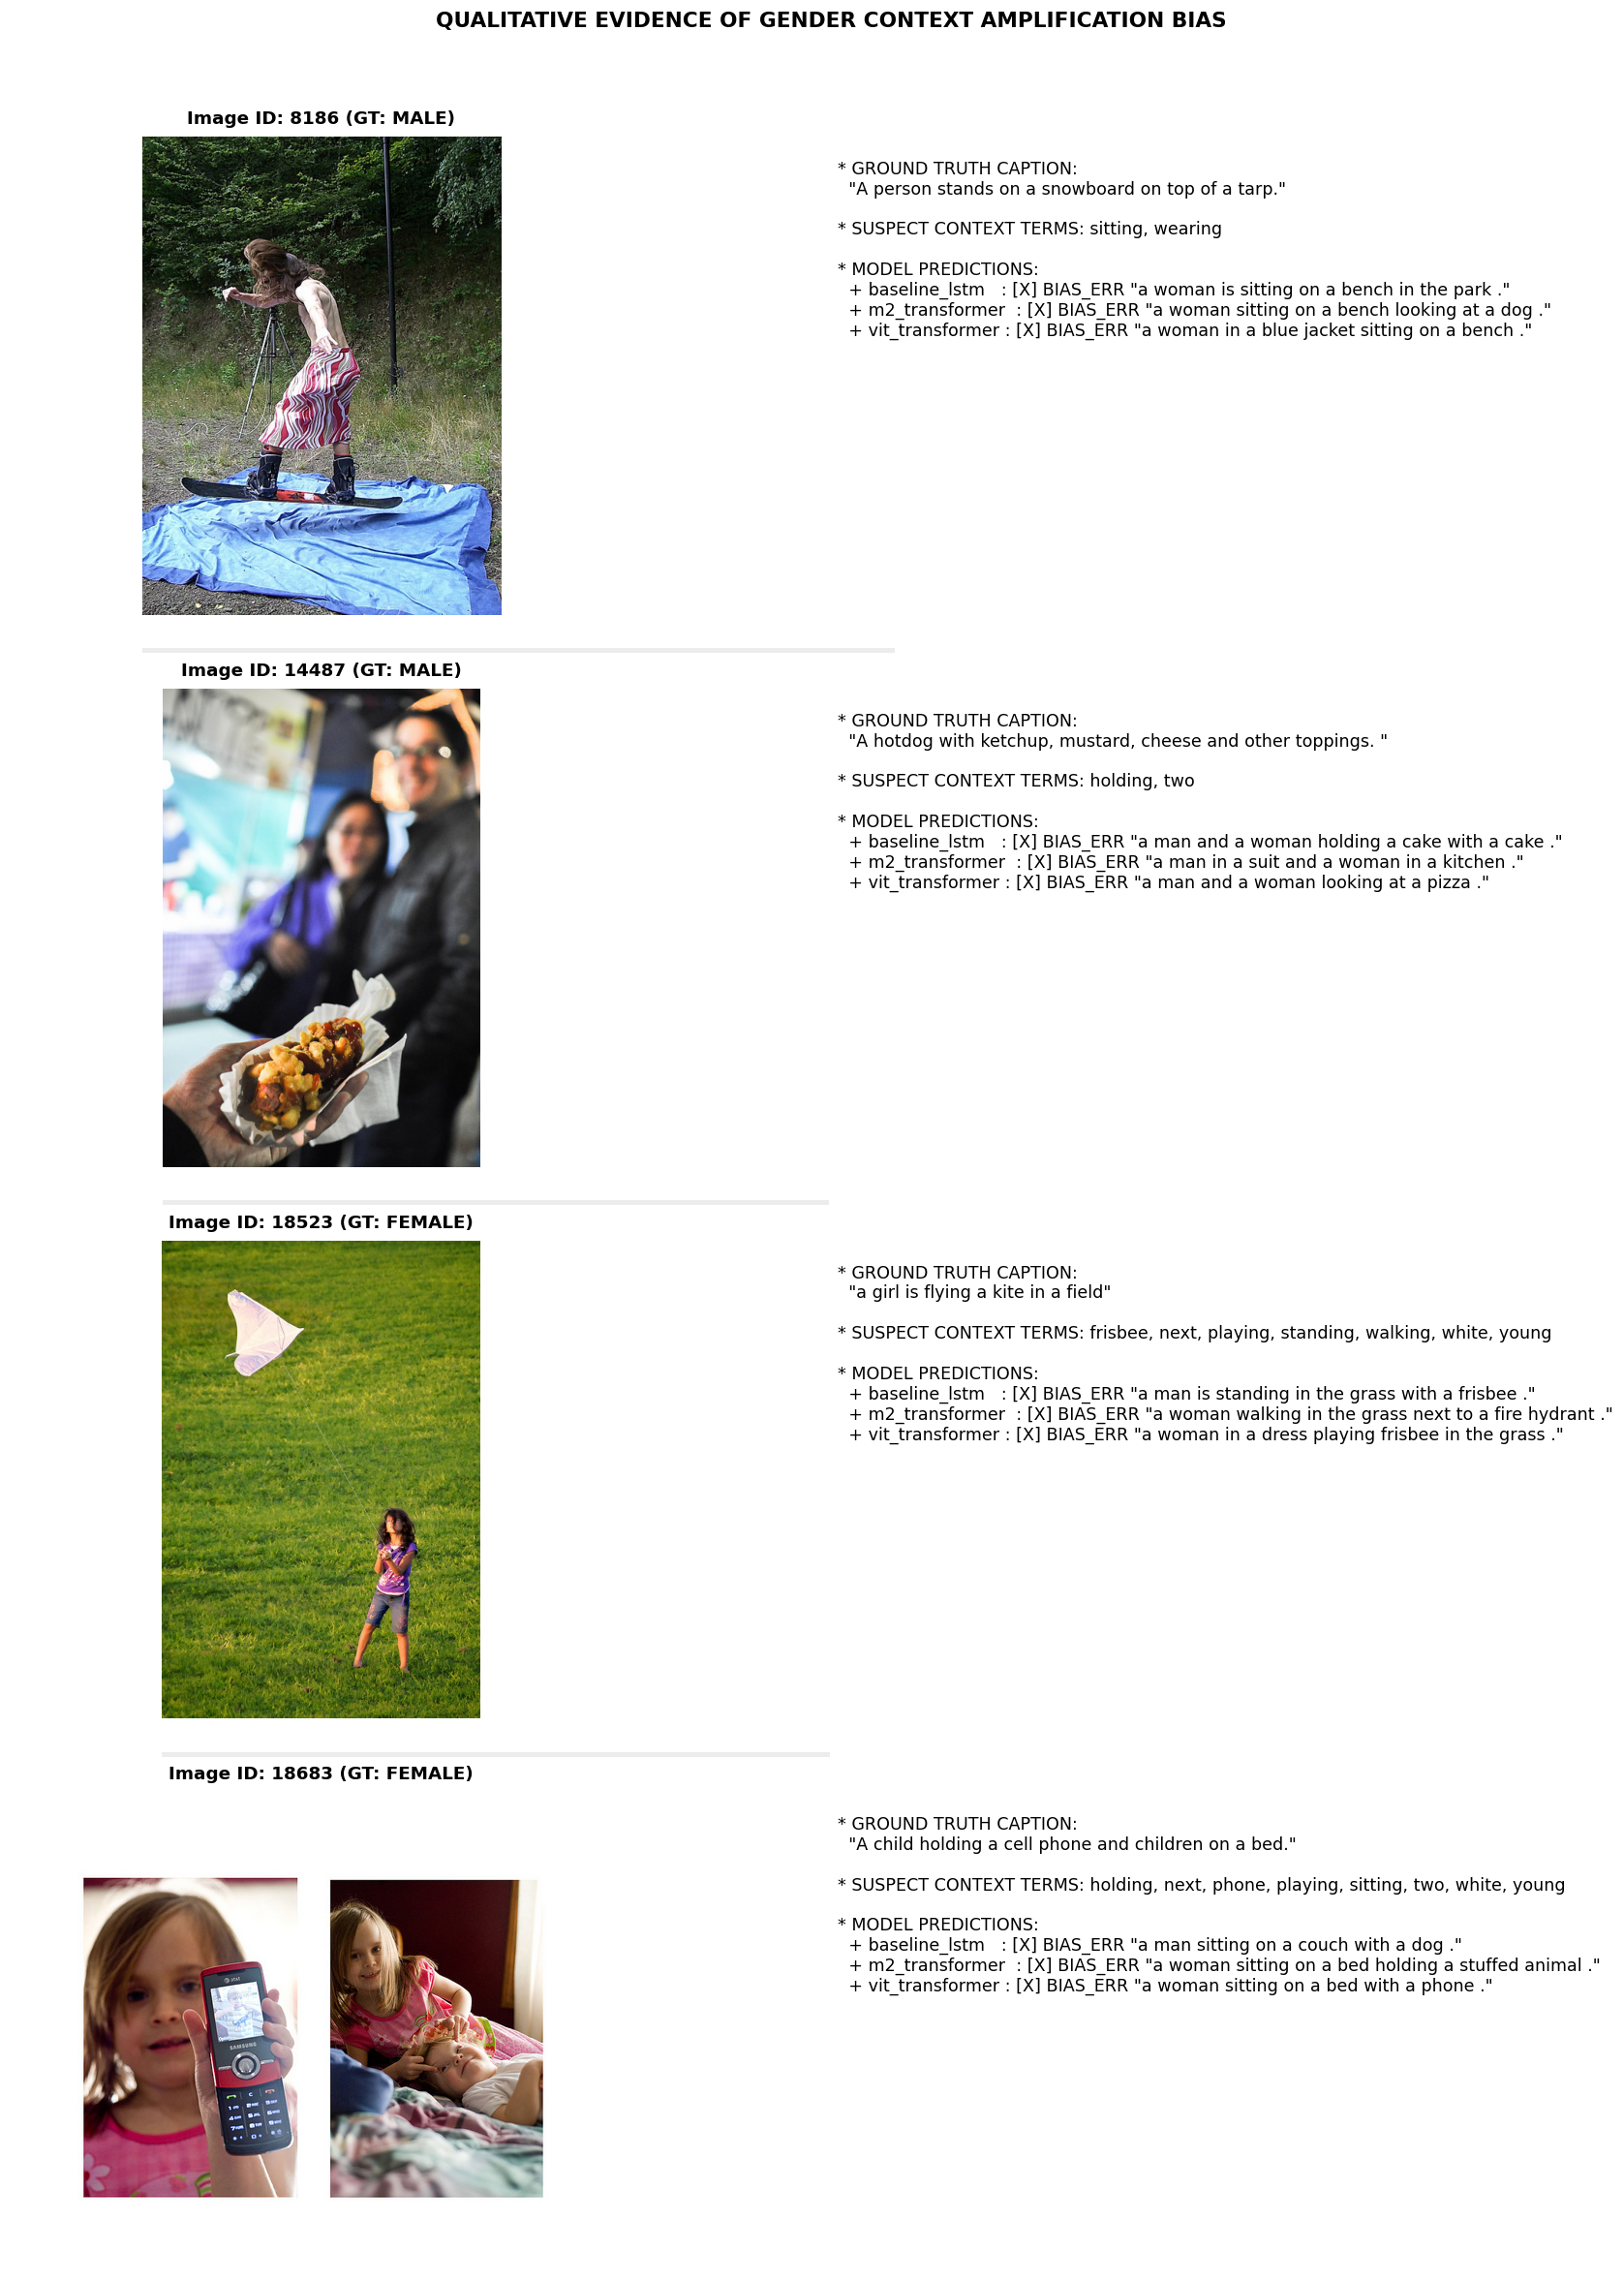

In [124]:
strict_error_cases = []
MALE_WORDS = {'man', 'men', 'boy', 'boys', 'guy', 'guys', 'gentleman'}
FEMALE_WORDS = {'woman', 'women', 'girl', 'girls', 'lady', 'ladies'}

for case in case_map.values():
    gt_text = " ".join(case.get('ground_truth_captions', [])).lower()
    
    # Xác định giới tính thực tế chính xác qua từ vựng câu gốc 
    has_male_gt = any(w in gt_text for w in MALE_WORDS)
    has_female_gt = any(w in gt_text for w in FEMALE_WORDS)
    
    # Chỉ xét những ảnh có giới tính gốc rõ ràng một bên (không lẫn lộn cả hai)
    if has_male_gt and not has_female_gt:
        real_gt_gender = 'male'
    elif has_female_gt and not has_male_gt:
        real_gt_gender = 'female'
    else:
        continue
        
    # Đếm số mô hình bị bối cảnh lừa đoán ngược lại giới tính gốc này
    mismatch_count = 0
    for model_name in ['baseline_lstm', 'm2_transformer', 'vit_transformer']:
        pred_cap = case['predictions'][model_name]['prediction'].lower()
        
        if real_gt_gender == 'male' and any(w in pred_cap for w in FEMALE_WORDS):
            mismatch_count += 1
        elif real_gt_gender == 'female' and any(w in pred_cap for w in MALE_WORDS):
            mismatch_count += 1
            
    if mismatch_count >= 2: # Ưu tiên ảnh đánh lừa được từ 2 đến 3 mô hình
        case['strict_mismatch_count'] = mismatch_count
        case['real_gt_gender'] = real_gt_gender
        strict_error_cases.append(case)

strict_error_cases = sorted(strict_error_cases, key=lambda x: x['strict_mismatch_count'], reverse=True)
selected_cases = strict_error_cases[:4]

if not selected_cases:
    print("No cases found matching the strict context bias criteria.")
else:
    fig, axes = plt.subplots(len(selected_cases), 2, figsize=(15, 4.8 * len(selected_cases)))
    
    for idx, (row_axes, case) in enumerate(zip(axes, selected_cases)):
        ax_img, ax_text = row_axes
        
        # Hiển thị ảnh bên trái
        image = Image.open(case['image_path']).convert('RGB')
        ax_img.imshow(image)
        ax_img.axis('off')
        ax_img.set_title(f"Image ID: {case['image_id']} (GT: {case['real_gt_gender'].upper()})", fontsize=11, fontweight='bold', pad=8)
        
        gt_preview = case['ground_truth_captions'][0] # Lấy câu mô tả gốc tiêu biểu nhất
        suspects = ", ".join(sorted(case.get('suspect_terms', []))) or "None"
        
        text_lines = [
            f"* GROUND TRUTH CAPTION:",
            f"  \"{gt_preview}\"",
            f"",
            f"* SUSPECT CONTEXT TERMS: {suspects}",
            f"",
            f"* MODEL PREDICTIONS:"
        ]
        
        for model_name in ['baseline_lstm', 'm2_transformer', 'vit_transformer']:
            pred_data = case['predictions'][model_name]
            pred_text = pred_data['prediction']
            
            # Đánh dấu lỗi nếu mô hình dự đoán sai giới tính
            is_wrong = (case['real_gt_gender'] == 'male' and any(w in pred_text.lower() for w in FEMALE_WORDS)) or \
                       (case['real_gt_gender'] == 'female' and any(w in pred_text.lower() for w in MALE_WORDS))
            
            marker = "[X] BIAS_ERR" if is_wrong else "[OK] CORRECT"
            
            text_lines.append(f"  + {model_name:<16}: {marker} \"{pred_text}\"")
            
        case_clean_text = "\n".join(text_lines)
        
        ax_text.axis('off')
        ax_text.text(0.02, 0.95, case_clean_text, ha='left', va='top', fontsize=10.5, fontfamily='sans-serif', transform=ax_text.transAxes)
        
        if idx < len(selected_cases) - 1:
            rect = plt.Rectangle((0, -0.08), 2.1, 0.01, facecolor='gray', alpha=0.15, transform=ax_img.transAxes, clip_on=False)
            ax_img.add_patch(rect)

    fig.suptitle('QUALITATIVE EVIDENCE OF GENDER CONTEXT AMPLIFICATION BIAS', y=1.02, fontsize=13, fontweight='bold')
    fig.tight_layout()
    path = save_figure(fig, 'bias_error_analysis_grid_clean.png')
    plt.show()

## Phase 4: OOV Analysis


**Quét tập Test xem có bao nhiêu từ không hề tồn tại trong tập Train (hoặc 
bị cắt bỏ do min_freq)**

In [127]:
with open(TRAIN_ANN_FILE, 'r', encoding='utf-8') as f:
    raw_train_words = {token for ann in json.load(f).get('annotations', []) for token in tokenize_caption(ann.get('caption', ''))}

# 2. Tính toán nhanh bằng hàm sum() toán học (Thay thế hoàn toàn vòng lặp for/if dài dòng)
below_threshold = sum(1 for word in phase4_oov_counter if word in raw_train_words)
strictly_new = phase4_unique_oov_words - below_threshold

# 3. In kết quả gọn gàng
print("\n" + "="*50)
print(f"Tổng số từ OOV (Out of Vocabulary): {phase4_unique_oov_words:,} từ")
print(f"  + Từ mới tinh (Train không có): {strictly_new:,} từ")
print(f"  + Từ bị lọc (Tần suất < {VOCAB_THRESHOLD}): {below_threshold:,} từ")
print("-" * 50)
print(f"Tổng số lần xuất hiện trong tập Test: {phase4_total_oov_tokens:,} lần ({phase4_oov_token_rate:.2f}%)")
print(f"Tỷ lệ câu bị dính từ OOV: {phase4_oov_sentence_rate:.2f}%")
print("="*50)


Tổng số từ OOV (Out of Vocabulary): 1,439 từ
  + Từ mới tinh (Train không có): 930 từ
  + Từ bị lọc (Tần suất < 5): 509 từ
--------------------------------------------------
Tổng số lần xuất hiện trong tập Test: 1,529 lần (0.54%)
Tỷ lệ câu bị dính từ OOV: 5.55%


**Nhận xét:**
Tỉ lệ OOV cho biết vocabulary train đang bỏ sót bao nhiêu tín hiệu trong test captions. Nếu các OOV này rơi vào gender, object hoặc context words quan trọng, chúng có thể ảnh hưởng cả chất lượng caption lẫn cách đọc bias của mô hình.


**Trực quan hóa**

Đã lưu biểu đồ thành công vào: /home/ngocanh/projects/Evaluating-the-evolution-of-Deep-Learning-architecture-in-the-Image-Captioning-problem/images/test_captions_oov_pie_chart.png


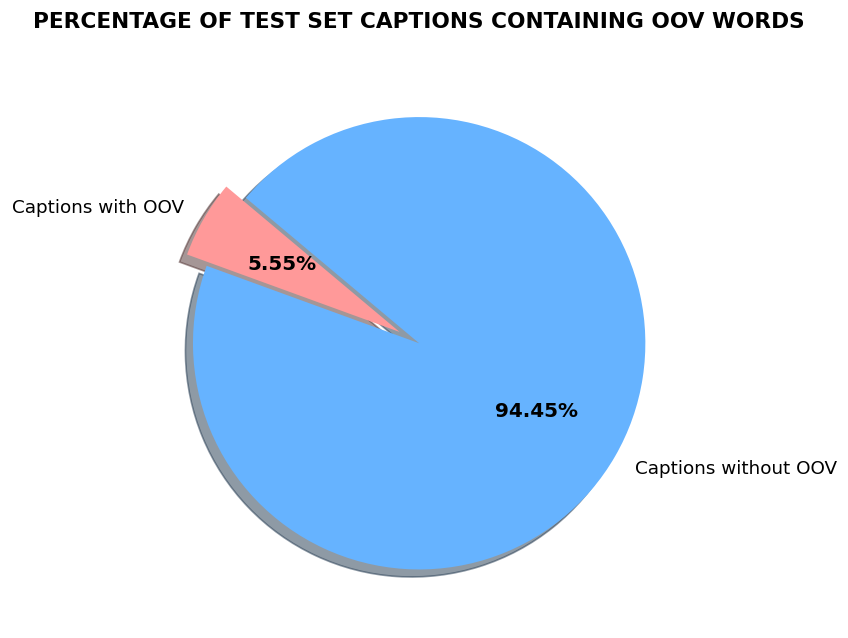

In [131]:
labels = ['Captions with OOV', 'Captions without OOV']
sizes = [phase4_captions_with_oov, phase4_captions_without_oov]
colors = ['#ff9999', '#66b3ff'] 
explode = (0.1, 0)  

fig, ax = plt.subplots(figsize=(7, 7))

# Vẽ Pie Chart
wedges, texts, autotexts = ax.pie(
    sizes, 
    explode=explode, 
    labels=labels, 
    colors=colors, 
    autopct='%1.2f%%', 
    shadow=True, 
    startangle=140,
    textprops=dict(color="black", fontsize=11)
)

for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_weight('bold')
    autotext.set_color('black')

ax.set_title('PERCENTAGE OF TEST SET CAPTIONS CONTAINING OOV WORDS', fontsize=13, fontweight='bold', pad=20)

fig.tight_layout()

if 'save_figure' in globals():
    path = save_figure(fig, 'test_captions_oov_pie_chart.png')
    print(f'Đã lưu biểu đồ thành công vào: {path}')
else:
    plt.savefig('test_captions_oov_pie_chart.png', dpi=300, bbox_inches='tight')
    print('Đã lưu biểu đồ thành công vào: test_captions_oov_pie_chart.png')

plt.show()

**Nhận xét:**

* **Tỷ lệ Captions không chứa OOV (94.45%):** Chiếm đại đa số tập Test. Con số này chứng minh bộ từ điển (Vocabulary) được xây dựng từ tập Train có độ bao phủ (*Coverage*) cực kỳ tốt, đủ vốn từ để hiểu hầu hết các ngữ cảnh mới.

* **Tỷ lệ Captions chứa OOV (5.55%):** Chiếm một phần rất nhỏ, cho thấy rủi ro mô hình gặp từ lạ và phải sinh ra token thay thế (`<unk>`) là rất thấp.

* **Hiệu quả của bộ lọc (`VOCAB_THRESHOLD`):** Khẳng định chiến lược thiết lập ngưỡng tần suất tối thiểu (`min_freq`) để loại bỏ từ hiếm ở tập Train là hoàn toàn đúng đắn. Việc này giúp tối ưu hóa tài nguyên hệ thống (giảm RAM, tăng tốc độ huấn luyện) nhưng vẫn giữ được độ chính xác ngôn ngữ khi sang tập Test.

* **Độ tin cậy của tập dữ liệu:** Tỷ lệ OOV thấp minh chứng hai tập Train và Test được phân chia phân phối đồng đều, không bị lệch pha ngôn ngữ (*Data Drift*), đảm bảo kết quả đánh giá của cả 3 mô hình đạt độ khách quan cao.